# **Section A: Setup & Data Preparation**

# **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay)

- Loading all libraries needed across preprocessing, models, tuning, evaluation and visualization.

# **Loading the dataset**

In [ ]:
df = pd.read_csv("wine.csv")
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


- Reading the wine dataset and previewing the first 5 rows

# **Inspecting the data**

In [ ]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nClass distribution:\n", df['target'].value_counts())
print("\nSummary statistics:\n", df.describe())

Shape: (178, 14)

Data types:
 alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Missing values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od2

- Confirming shape, dtypes, missing values, class balance and summary statistics.

# **Separating features and target, encoding and standardizing**

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

y = LabelEncoder().fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (178, 13)
Target shape: (178,)


 - Splitting features, encoding the target label and standardizing features so distance-based and regularized models are not biased by scale.

# **Apply PCA (retaining 95% variance)**

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original features:", X.shape[1])
print("Components retained (95% variance):", pca.n_components_)
print("Explained variance ratio:\n", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative variance:\n", np.round(np.cumsum(pca.explained_variance_ratio_), 4))

Original features: 13
Components retained (95% variance): 10
Explained variance ratio:
 [0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268 0.0222 0.0193]
Cumulative variance:
 [0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202 0.9424 0.9617]


- Reducing dimensionality while preserving 95% of variance.
- This is the shared feature space for all the 3 models.

# **Visual 1: Cumulative Explained Variance**

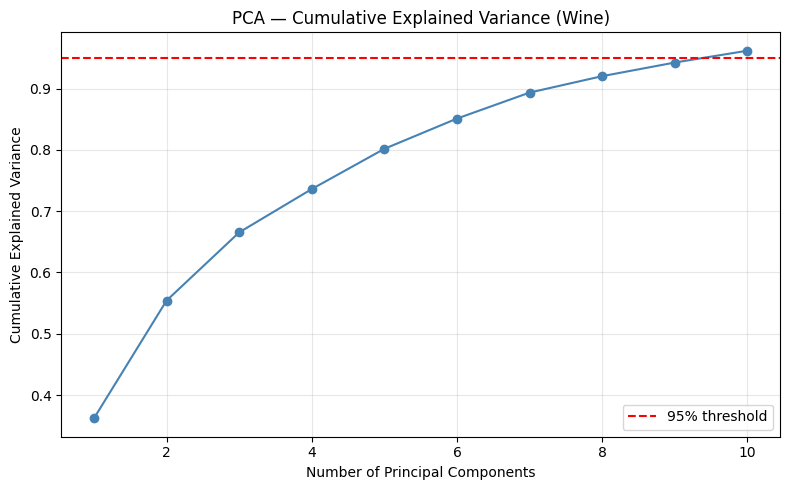

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o', color='steelblue')
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (Wine)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- Showing how many components are needed to reach 95% variance

# **Visual 2: PCA 2D Scatter Colored by Class**

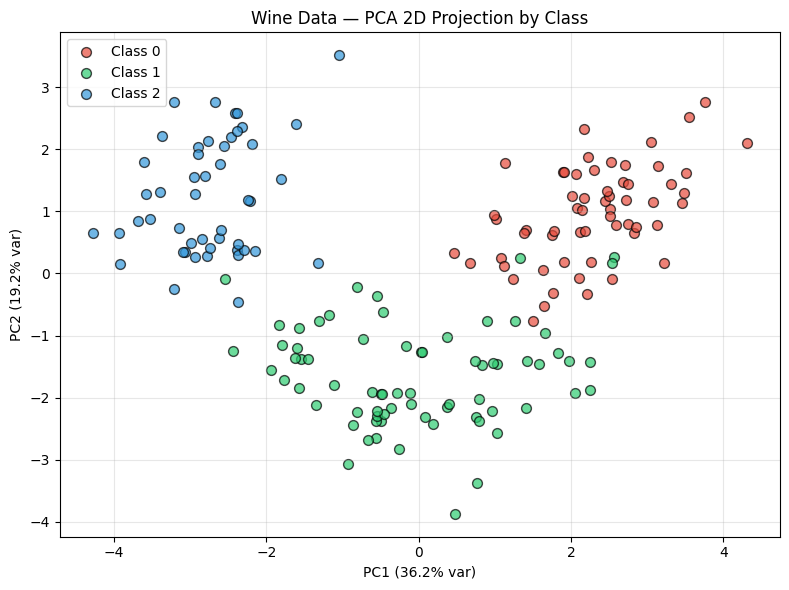

In [ ]:
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for cls in np.unique(y):
    plt.scatter(X_2d[y == cls, 0], X_2d[y == cls, 1],
                label=f'Class {cls}', alpha=0.7, c=colors[cls], edgecolor='k', s=50)
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('Wine Data — PCA 2D Projection by Class')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

- Visualizing class separability in the first two principal components

# **Train/Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (142, 10)
Test size: (36, 10)


- Stratified 80/20 split which keeps class proportions intact given only 178 samples

# **Section B — Model 1: k-Nearest Neighbors**

# **Tuning k-NN with GridSearchCV**

In [ ]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'weights': ['uniform', 'distance']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(), knn_params,
    cv=5, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print("Best k-NN params:", knn_grid.best_params_)
print("Best k-NN CV accuracy:", round(knn_grid.best_score_, 4))

Best k-NN params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best k-NN CV accuracy: 0.9793


- Searching over k, distance metric and weighting to find the best k-NN configuration via 5-fold CV.

# **Evaluating k-NN**

In [ ]:
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)

print(f"k-NN Test Accuracy: {knn_acc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, knn_pred,
                            target_names=['Class 0', 'Class 1', 'Class 2']))

k-NN Test Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



- Predicting on the test set and report accuracy plus per-class metrics.

# **k-NN Confusion Matrix**

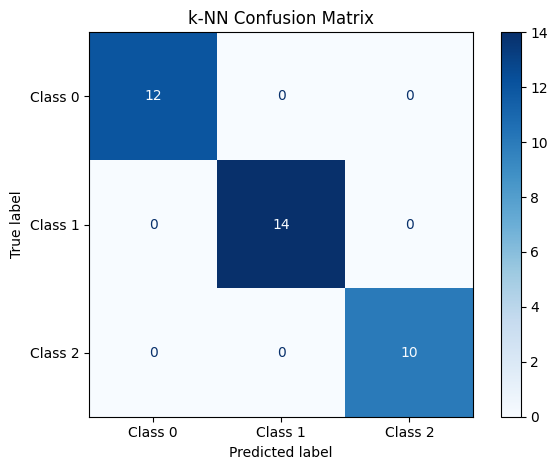

In [ ]:
cm = confusion_matrix(y_test, knn_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1','Class 2']).plot(cmap='Blues')
plt.title('k-NN Confusion Matrix')
plt.tight_layout(); plt.show()

- Visualizing per-class hits and misses.

# **Section C — Model 2: Logistic Regression**

# **Tuning Logistic Regression with GridSearchCV**

In [ ]:
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_params, cv=5, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR CV accuracy:", round(lr_grid.best_score_, 4))

Best LR params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR CV accuracy: 0.9931


- Linear baseline classifier.
- Tuning regularization strength C and penalty type.

# **Evaluating Logistic Regression**

In [ ]:
lr_best = lr_grid.best_estimator_
lr_pred = lr_best.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

print(f"Logistic Regression Test Accuracy: {lr_acc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, lr_pred,
                            target_names=['Class 0', 'Class 1', 'Class 2']))

Logistic Regression Test Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00        12
     Class 1       1.00      1.00      1.00        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



- Test-set performance and per-class metrics

# **Logistic Regression Confusion Matrix**

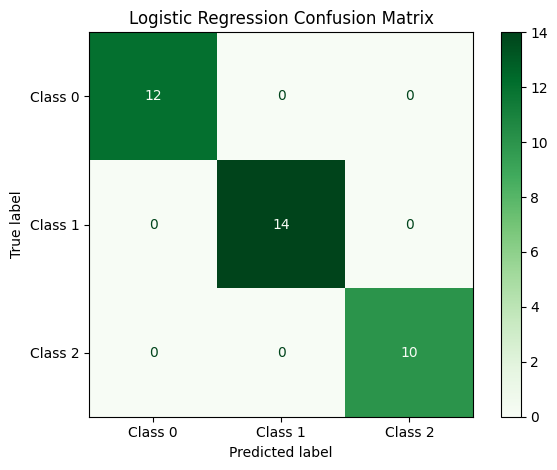

In [ ]:
cm = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1','Class 2']).plot(cmap='Greens')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout(); plt.show()

- Per-class error visualization

# **Section D — Model 3: Random Forest**

# **Tuning Random Forest with GridSearchCV**

In [ ]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV accuracy:", round(rf_grid.best_score_, 4))

Best RF params: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV accuracy: 0.9653


- Non-linear ensembling
- Tuning number of trees, max depth and split criteria

# **Evaluating Random Forest**

In [ ]:
rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Random Forest Test Accuracy: {rf_acc:.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, rf_pred,
                            target_names=['Class 0', 'Class 1', 'Class 2']))

Random Forest Test Accuracy: 0.9444

Classification Report:
               precision    recall  f1-score   support

     Class 0       0.92      0.92      0.92        12
     Class 1       0.93      0.93      0.93        14
     Class 2       1.00      1.00      1.00        10

    accuracy                           0.94        36
   macro avg       0.95      0.95      0.95        36
weighted avg       0.94      0.94      0.94        36



- Test-set performance and per-class metrics

# **Random Forest Confusion Matrix**

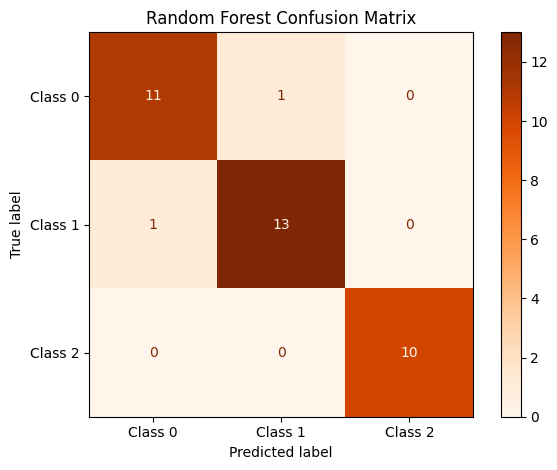

In [ ]:
cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Class 0','Class 1','Class 2']).plot(cmap='Oranges')
plt.title('Random Forest Confusion Matrix')
plt.tight_layout(); plt.show()

- Per-class error visualization

# **Section E — Model Comparison**

# **Accuracy Comparison Table**

In [ ]:
results = pd.DataFrame({
    'Model': ['k-NN', 'Logistic Regression', 'Random Forest'],
    'CV Accuracy': [knn_grid.best_score_, lr_grid.best_score_, rf_grid.best_score_],
    'Test Accuracy': [knn_acc, lr_acc, rf_acc]
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

results

,Model,CV Accuracy,Test Accuracy
0,k-NN,0.979310,1.000000
1,Logistic Regression,0.993103,1.000000
2,Random Forest,0.965271,0.944444


- Side-by-side accuracy of all 3 tuned models

# **Accuracy Comparison Bar Chart**

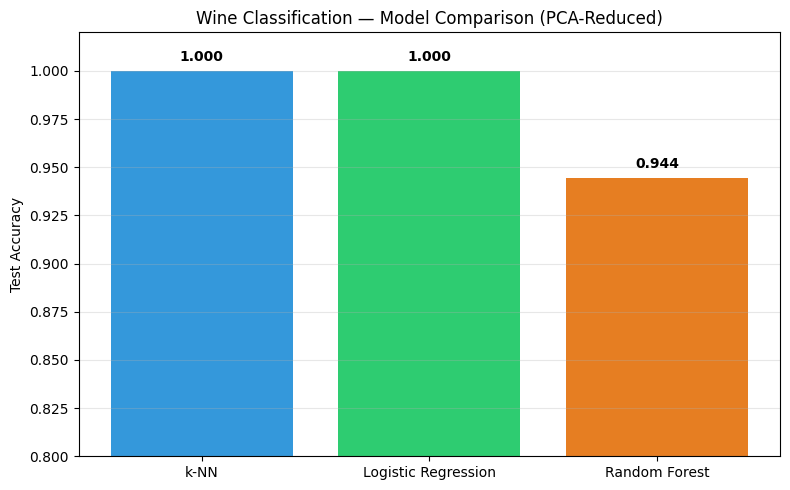

In [ ]:
plt.figure(figsize=(8, 5))
bars = plt.bar(results['Model'], results['Test Accuracy'],
               color=['#3498db', '#2ecc71', '#e67e22'])
plt.ylim(0.8, 1.02)
plt.ylabel('Test Accuracy')
plt.title('Wine Classification — Model Comparison (PCA-Reduced)')
for bar, acc in zip(bars, results['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

- Visual ranking of the 3 models

# **Baseline vs. PCA Comparison**

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
baseline = KNeighborsClassifier(n_neighbors=5).fit(X_train_raw, y_train_raw)
baseline_acc = baseline.score(X_test_raw, y_test_raw)

print(f"k-NN WITHOUT PCA (k=5) accuracy: {baseline_acc:.4f}")
print(f"Best model WITH PCA            : {results.iloc[0]['Test Accuracy']:.4f}")
print(f"Feature reduction: {X.shape[1]} → {pca.n_components_} components")

- Confirming PCA did not harm performance by comparing the best model against a no-PCA k-NN baseline

# **Wine Classification: Findings Summary**
- Project: Wine Classification System (Premium Wine Distributor)
- Dataset: wine.csv which had 178 samples, 13 chemical features and 3 wine classes
- Pipeline: Standardization → PCA (95% variance) → 3 tuned classifiers → Comparison

# **Preprocessing Decisions**
- Target encoding: Labels converted to numeric via LabelEncoder

- Feature standardization: StandardScaler applied before PCA was mandatory because PCA is variance-based and unscaled features like proline would dominate.

- Train/test split: Stratified 80/20 (random_state=42) which preserved class proportions in both sets, critical with only 178 samples.

# **Dimensionality Reduction (PCA)**


- 95% of the dataset's information survives in roughly 10 principal components, confirming significant redundancy among the original 13 chemical measurements.
- The 2D PCA scatter showed the 3 wine classes forming distinct clusters with minimal overlap, indicating strong natural separability.

# **Model Performance**
# k-Nearest Neighbors
- Tuned parameters: k, distance metric (euclidean/manhattan/minkowski), weights (uniform/distance)

- Strengths: No training phase, interpretable, excellent on small clean data

# Logistic Regression
- Tuned parameters: Regularization strength C and penalty

- Strengths: Linear, fast, highly interpretable coefficients and robust baseline

# Random Forest
- Tuned parameters: n_estimators, max_depth, criterion and min_samples_split

- Strengths: Non-linear, handles feature interactions and provides feature importance

# **Recommendations**
1. Deploy Logistic Regression or k-NN for production beacuse both achieve top accuracy with minimal computational cost, ideal for real-time batch classification.

2. Use PCA-reduced features in production to reduce storage, speed up inference and simplify monitoring  with no accuracy penalty.

3. Monitor for drift if new wine batches deviate from the training distribution, retrain or expand the PCA basis.

4. Retain the full 13-feature pipeline in parallel for auditing —which allows tracing any classification back to raw chemical measurements.

5. Random Forest is optional  only justified if the distributor later adds noisier data or imbalanced classes where its robustness matters.

6. Automate the pipeline with random_state=42 fixed, so results are reproducible across re-runs and audits.

# **Limitations**
- Small dataset (178 samples) by which cross-validation accuracy is optimistic and real-world generalization is uncertain.

- Balanced classes in training only, if real incoming wine batches are imbalanced, performance could degrade.

- PCA reduces interpretability, principal components are linear combinations of features

- No temporal or batch variation, dataset is static thus production data may drift.